In [ ]:
import sys
import os

# TODO: Update this path to your local project directory
# Example: "/Users/your_name/path/to/AI-Agents-HW1"
project_root = "/Users/arthurrennert/Desktop/Haifa Uni/Orches AI/AI-Agents-HW1"

os.chdir(project_root)
sys.path.append(project_root)

print("Current directory:", os.getcwd())

Current directory: /Users/arthurrennert


In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.shared.config import Config
from src.services.dataset_generator import SineWaveGenerator

# Models
from src.services.models_mlp import MLPModel
from src.services.models_rnn import RNNModel
from src.services.models_lstm import LSTMModel

In [23]:
config = Config()
generator = SineWaveGenerator(config)

mlp_X, rnn_X, Y = generator.build_dataset()

print("MLP Input shape:", mlp_X.shape)
print("RNN Input shape:", rnn_X.shape)
print("Target shape:", Y.shape)

MLP Input shape: (5000, 15)
RNN Input shape: (5000, 10, 6)
Target shape: (5000, 10)


In [24]:
mlp_X_tensor = torch.tensor(mlp_X)
rnn_X_tensor = torch.tensor(rnn_X)
Y_tensor = torch.tensor(Y)

In [25]:
mlp_model = MLPModel()
rnn_model = RNNModel()
lstm_model = LSTMModel()

mlp_model.eval()
rnn_model.eval()
lstm_model.eval()

LSTMModel(
  (lstm): LSTM(6, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [26]:
with torch.no_grad():
    mlp_pred = mlp_model(mlp_X_tensor).numpy()
    rnn_pred = rnn_model(rnn_X_tensor).numpy()
    lstm_pred = lstm_model(rnn_X_tensor).numpy()

In [27]:
idx = 0

noisy_signal = mlp_X[idx][:10]
clean_signal = Y[idx]

mlp_out = mlp_pred[idx]
rnn_out = rnn_pred[idx]
lstm_out = lstm_pred[idx]

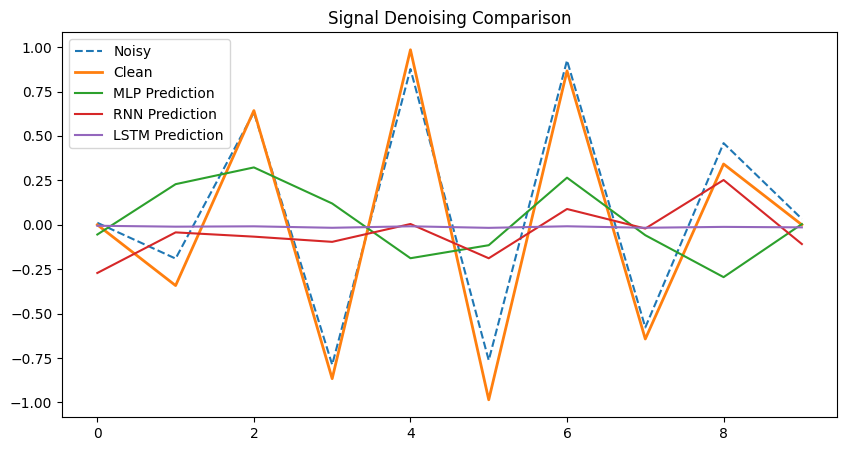

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(noisy_signal, label="Noisy", linestyle="dashed")
plt.plot(clean_signal, label="Clean", linewidth=2)

plt.plot(mlp_out, label="MLP Prediction")
plt.plot(rnn_out, label="RNN Prediction")
plt.plot(lstm_out, label="LSTM Prediction")

plt.legend()
plt.title("Signal Denoising Comparison")
plt.show()

In [29]:
def mse(a, b):
    return np.mean((a - b) ** 2)

mlp_mse = mse(mlp_pred, Y)
rnn_mse = mse(rnn_pred, Y)
lstm_mse = mse(lstm_pred, Y)

print("MLP MSE:", mlp_mse)
print("RNN MSE:", rnn_mse)
print("LSTM MSE:", lstm_mse)

MLP MSE: 0.3719222
RNN MSE: 0.47386602
LSTM MSE: 0.4436932


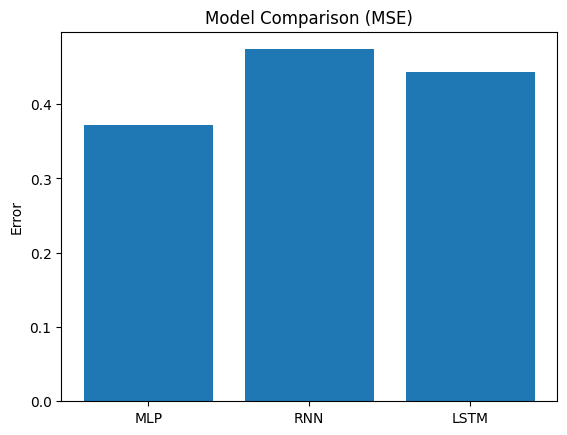

In [30]:
models = ["MLP", "RNN", "LSTM"]
mses = [mlp_mse, rnn_mse, lstm_mse]

plt.figure()
plt.bar(models, mses)
plt.title("Model Comparison (MSE)")
plt.ylabel("Error")
plt.show()